# 门控循环单元（GRU）

## 1. 为什么需要GRU

普通RNN存在的问题有梯度消失、梯度爆炸且难以学习长期依赖。  
GRU通过“门控机制”解决这些问题

## 2. GRU的核心思想

在RNN基础上加入“门（gate）”，控制信息流决定保留多少旧信息、决定接收多少新信息、决定是否清空记忆。  


## 3. 两个核心门

重置门 Rₜ

Rₜ = σ(XₜWₓᵣ + Hₜ₋₁Wₕᵣ + bᵣ)

用于控制是否“忘记过去”，决定旧状态参与程度

更新门 Zₜ

Zₜ = σ(XₜWₓ𝓏 + Hₜ₋₁Wₕ𝓏 + b𝓏)

用于控制新旧状态的融合比例，决定保留旧信息还是更新


## 4. 候选隐状态

$\tilde{\mathbf{H}}_t \in \mathbb{R}^{n \times h}$。


$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{xh} + \left(\mathbf{R}_t \odot \mathbf{H}_{t-1}\right) \mathbf{W}_{hh} + \mathbf{b}_h),$$

先用重置门筛选旧信息，再结合当前输入生成新候选状态。  


## 5. 最终隐状态

$$\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1}  + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t.$$


Zₜ ≈ 1 保留旧状态（记忆不变）  
Zₜ ≈ 0 使用新状态（更新记忆）  


总之，门控循环单元具有以下两个显著特征：

* 重置门有助于捕获序列中的短期依赖关系；
* 更新门有助于捕获序列中的长期依赖关系。


从零开始实现，读取时间机器数据集。

In [1]:
import torch
import re
import requests
from collections import Counter


url = "http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
file_path = "timemachine.txt"

response = requests.get(url)
with open(file_path, "wb") as f:
    f.write(response.content)


def read_time_machine():
    with open(file_path, 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()


tokens = [list(line) for line in lines]
corpus = [char for line in tokens for char in line]


class Vocab:
    def __init__(self, tokens):
        counter = Counter(tokens)
        self.idx_to_token = list(counter.keys())
        self.token_to_idx = {token: i for i, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        return self.token_to_idx[token]

vocab = Vocab(corpus)

# 转为索引
corpus = [vocab[token] for token in corpus]

def load_data_time_machine(batch_size, num_steps):
    corpus_tensor = torch.tensor(corpus, dtype=torch.long)

    num_tokens = (len(corpus_tensor) // batch_size) * batch_size
    corpus_tensor = corpus_tensor[:num_tokens]

    corpus_tensor = corpus_tensor.reshape(batch_size, -1)

    num_batches = (corpus_tensor.shape[1] - 1) // num_steps

    data = []
    for i in range(0, num_batches * num_steps, num_steps):
        X = corpus_tensor[:, i:i+num_steps]
        Y = corpus_tensor[:, i+1:i+num_steps+1]
        data.append((X, Y))

    return data, vocab


batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

for X, Y in train_iter:
    print(X.shape, Y.shape)
    break

torch.Size([32, 35]) torch.Size([32, 35])


初始化模型参数

 我们从标准差为 0.01 的高斯分布中提取权重， 并将偏置项设为 0 ，超参数num_hiddens定义隐藏单元的数量， 实例化与更新门、重置门、候选隐状态和输出层相关的所有权重和偏置。

In [2]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()  # 更新门参数
    W_xr, W_hr, b_r = three()  # 重置门参数
    W_xh, W_hh, b_h = three()  # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

定义模型

定义隐状态的初始化函数init_gru_state，此函数返回一个形状为（批量大小，隐藏单元个数）的张量，张量的值全部为零。

In [3]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

定义门控循环单元模型

模型的架构与基本的循环神经网络单元是相同的

In [4]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

训练与预测

训练结束后，我们分别打印输出训练集的困惑度， 以及前缀“time traveler”和“traveler”的预测序列上的困惑度。

In [6]:
import torch
import torch.nn.functional as F

class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state = init_state
        self.forward_fn = forward_fn
        self.device = device

    def __call__(self, X, state):
        # one-hot 编码
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

In [7]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = vocab_size
    num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()
    W_xr, W_hr, b_r = three()
    W_xh, W_hh, b_h = three()

    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    params = [W_xz, W_hz, b_z,
              W_xr, W_hr, b_r,
              W_xh, W_hh, b_h,
              W_hq, b_q]

    for param in params:
        param.requires_grad_(True)

    return params

In [8]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)

In [10]:
import torch

def grad_clipping(net, theta):
    if isinstance(net, torch.nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params

    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [11]:
import time
import math
from torch import nn

def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    state = None
    start_time = time.time()
    metric = [0.0, 0]

    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(X.shape[0], device)
        else:
            if isinstance(state, tuple):
                state = tuple(s.detach() for s in state)
            else:
                state = state.detach()

        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)

        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()

        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(batch_size=1)

        metric[0] += l.item() * y.numel()
        metric[1] += y.numel()

    return math.exp(metric[0] / metric[1]), metric[1] / (time.time() - start_time)

In [12]:
import matplotlib.pyplot as plt

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    loss = nn.CrossEntropyLoss()

    # 优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr=lr)
    else:
        def updater(batch_size):
            for param in net.params:
                param.data -= lr * param.grad / batch_size
                param.grad.zero_()

    ppl_list = []
    epoch_list = []

    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )

        if (epoch + 1) % 10 == 0:
            print(f'epoch {epoch+1}, ppl {ppl:.3f}')
            ppl_list.append(ppl)
            epoch_list.append(epoch + 1)

    print(f'最终困惑度 {ppl:.1f}, {speed:.1f} tokens/sec')

    # 画图
    plt.plot(epoch_list, ppl_list)
    plt.xlabel('epoch')
    plt.ylabel('perplexity')
    plt.grid()
    plt.show()

epoch 10, ppl 7.937
epoch 20, ppl 6.249
epoch 30, ppl 5.262
epoch 40, ppl 4.574
epoch 50, ppl 4.019
epoch 60, ppl 3.510
epoch 70, ppl 3.099
epoch 80, ppl 2.820
epoch 90, ppl 2.642
epoch 100, ppl 2.498
epoch 110, ppl 2.391
epoch 120, ppl 2.301
epoch 130, ppl 2.236
epoch 140, ppl 2.190
epoch 150, ppl 2.140
epoch 160, ppl 2.100
epoch 170, ppl 2.067
epoch 180, ppl 2.042
epoch 190, ppl 2.012
epoch 200, ppl 1.987
epoch 210, ppl 1.964
epoch 220, ppl 1.950
epoch 230, ppl 1.935
epoch 240, ppl 1.914
epoch 250, ppl 1.901
epoch 260, ppl 1.891
epoch 270, ppl 1.879
epoch 280, ppl 1.867
epoch 290, ppl 1.863
epoch 300, ppl 1.857
epoch 310, ppl 1.845
epoch 320, ppl 1.834
epoch 330, ppl 1.825
epoch 340, ppl 1.816
epoch 350, ppl 1.811
epoch 360, ppl 1.806
epoch 370, ppl 1.792
epoch 380, ppl 1.789
epoch 390, ppl 1.786
epoch 400, ppl 1.771
epoch 410, ppl 1.773
epoch 420, ppl 1.765
epoch 430, ppl 1.763
epoch 440, ppl 1.751
epoch 450, ppl 1.749
epoch 460, ppl 1.741
epoch 470, ppl 1.740
epoch 480, ppl 1.734
e

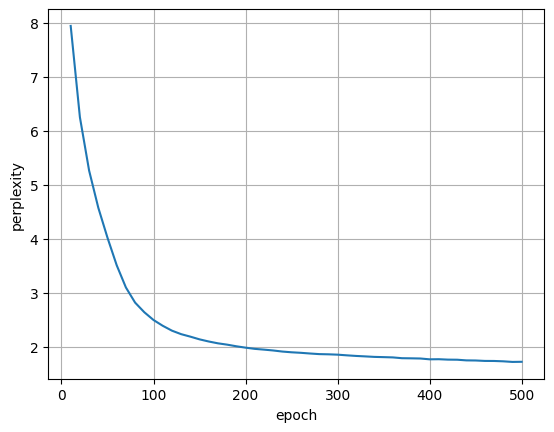

In [13]:
import torch

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 超参数
vocab_size, num_hiddens = len(vocab), 256
num_epochs, lr = 500, 1

# 模型
model = RNNModelScratch(
    vocab_size,
    num_hiddens,
    device,
    get_params,
    init_gru_state,
    gru
)

# 训练
train_ch8(model, train_iter, vocab, lr, num_epochs, device)